In [6]:
import pandas as pd


In [7]:
df = pd.read_pickle("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/data/environment_data/participant_data_4_groups_one-sided.pkl")

In [8]:
df = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/merged_data_full.csv")

## Check differnces in cumulated_TA_costs

In [9]:
df_error = df[df["participant_code"] == "bg0sc88i"]

In [5]:
# 1. Compute the group‐level difference and add it as a new column
df['group_diff'] = (
    df
    .groupby(['session_id', 'round', 'group_id_in_round'])['cumulated_TA_costs']
    .transform(lambda x: x.max() - x.min())
)

# 2. Filter to only those negotiations (groups) where the difference > 0.15
affected_df = df[df['group_diff'] > 0.16].sort_values('negotiation_id')

# 3. Optionally, view unique group identifiers that are affected
errors = (
    affected_df
    [['session_id', 'round', 'group_id_in_round']]
    .drop_duplicates()
    .reset_index(drop=True)
)



## Check Weird Payoff Datapoint t12

In [4]:
df_t12 = df[df['treatment'].isin(['T1', 'T2'])].copy()
df_weird = df_t12[(df_t12['payoff'] < -5) & (df_t12['bargaining_outcome'] == 'Random_Termination')]
df_weird_2 = df[df['negotiation_id'] == 2527].copy()
df_weird_3 = df[df['participant_code'] == "xqkxyb1f"].copy()

## Check answer to timing quesiton

In [3]:
data = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/data/main/asymmetric_TA/july_8.csv")
data = data[["bargain_live.33.player.offer_timing_question", "participant.role_in_game"]]
data.to_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/july_8_offer_timing_question.csv", index=False)

# Check data quality asymetric TA round 2

In [5]:
df = df[(df["session_id"] == "ltd48klq")]
df_error = df[df['last_offer_time'] > df['bargaining_time_full_sec']]
#df_error = df[df["negotiation_id"]== 1711]
len(df_error)

3

In [ ]:
#df_error = df[df['last_offer_time'] > df['bargaining_time_full_sec']]
print(len(df_error))
print(sum(df_error['termination_time_sec']!= df_error['bargaining_time_full_sec']))
average_diff = abs(df_error['last_offer_time'] - df_error['bargaining_time_full_sec']).mean()
print(f"{average_diff:.4f}")


3
0
1.5367


In [11]:
error_monitor = df_error[['last_offer_time', 'bargaining_time_full_sec', 'termination_time_sec', 'session_id', 'participant_role', 'treatment', 'terminated_by_id_in_group', 'id_in_group']].copy()

In [34]:
cols = list(df_error.columns)
# Reorder the DataFrame
#df_error = df_error[["bargaining_time_full_sec", "last_offer_time"] + cols]
df_error["difference_timiing"] = df_error.loc["last_offer_time"] - df_error.loc["bargaining_time_full_sec"]

KeyError: 'last_offer_time'

In [ ]:
df = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/merged_data_full.csv")

In [9]:
df_error = df[df['payoff'] > 1000]

<Axes: ylabel='Frequency'>

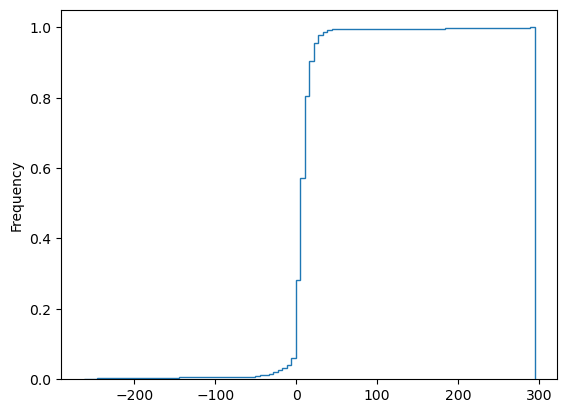

In [7]:
df["payoff"].plot(kind='hist', cumulative=True, density=True, bins=100, histtype='step')

<Axes: >

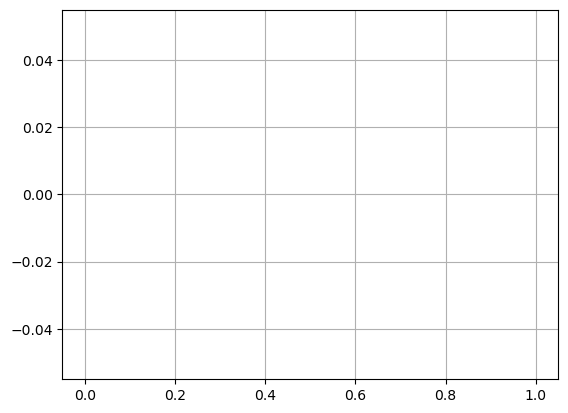

In [4]:
df["payoff"].hist()

In [9]:
df_price_difference = df[abs(df["deal_price"] - df["deal_price_raw"]) > 0.1]


In [8]:
error = df.loc[
        df['negotiation_id'] == 1302
    ]

error_2 = df.loc[
        df['participant_code'] == "377qgc0k"
    ]

In [26]:
error_3 = df[df["payoff"] < -100]

In [27]:
df_t3 = df[df["treatment"] == "T3"][["acceptance_time_raw", "offer_amount_list", "offer_time_list"]]

In [28]:
error = df[df["offer_time_1"] > (df["termination_time_sec"] + 3)][["negotiation_id",  "acceptance_time_raw", "termination_time_raw", "bargaining_time_full_sec", "offer_amount_list", "offer_time_list", "id_in_group", "terminated_by_id_in_group", "participant_code", "treatment", "cumulated_TA_costs", "acceptance_time_sec"]]

KeyError: "['cumulated_TA_costs'] not in index"

In [85]:
print(len(error))
print(sorted(error["participant_code"].unique()))

29
['1iks56mv', '5g3kc3sd', 'fcg9wvhl', 'geiytk1f', 'j77eg3cz', 'jlps4e97', 'ltx7dkd0']


In [86]:
error_2 = df[df["offer_time_1"] > (df["acceptance_time_sec"] + 3)][["negotiation_id",  "acceptance_time_raw", "termination_time_raw", "bargaining_time_full_sec", "offer_amount_list", "offer_time_1", "offer_time_list", "id_in_group", "accepted_by_id_in_group", "participant_code", "treatment", "cumulated_TA_costs", "acceptance_time_sec"]]

In [87]:
print(len(error_2))
print(sorted(error_2["participant_code"].unique()))

45
['5g3kc3sd', 'geiytk1f', 'j77eg3cz', 'jlps4e97', 'lor2yob7', 'ltx7dkd0', 'nko8v9ll', 'pn6bj1oy']


In [88]:
error_3 = df[df["negotiation_id"] == 618][["negotiation_id", "offer_time_1", "acceptance_time_sec", "termination_time_sec", "bargaining_time_full_sec", "offer_amount_list", "offer_time_list", "offer_time_1", "id_in_group", "accepted_by_id_in_group", "participant_code", "treatment", "cumulated_TA_costs", "acceptance_time_sec"]]

In [89]:
error_4 = df[(df["offer_time_1"] > 500)][["negotiation_id",  "acceptance_time_raw", "termination_time_raw", "bargaining_time_full_sec", "offer_amount_list", "offer_time_list", "id_in_group", "accepted_by_id_in_group", "participant_label", "treatment", "cumulated_TA_costs", "acceptance_time_sec"]]
print(len(error_4))

0


In [90]:
error_5 = df[df["last_offer_time"] > (df["bargaining_time_full_sec"] + 3)][["negotiation_id",  "acceptance_time_raw", "termination_time_raw", "bargaining_time_full_sec", "offer_amount_list", "offer_time_1", "offer_time_list", "id_in_group", "accepted_by_id_in_group", "participant_code", "last_offer_time", "treatment", "cumulated_TA_costs", "acceptance_time_sec"]]

In [91]:
print(len(error_5))
print(sorted(error_5["participant_code"].unique()))

105
['1iks56mv', '5g3kc3sd', 'fcg9wvhl', 'geiytk1f', 'j77eg3cz', 'jlps4e97', 'lor2yob7', 'ltx7dkd0', 'nko8v9ll', 'pn6bj1oy']


In [93]:
error_6 = df[df["participant_code"] == "ltx7dkd0"][["negotiation_id",  "acceptance_time_raw", "termination_time_raw", "bargaining_time_full_sec", "offer_amount_list", "offer_time_1", "offer_time_list", "id_in_group", "accepted_by_id_in_group", "participant_code", "last_offer_time", "treatment", "cumulated_TA_costs", "acceptance_time_sec"]]